# Training

---

### Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, precision_recall_curve,
)

---

### Loading dataset

In [34]:
df = pd.read_csv("../data/data_training.csv")

In [35]:
df["event_time"] = pd.to_datetime(df["event_time"], format="ISO8601")
df = df.sort_values(["account_id", "event_time"]).reset_index(drop=True)

In [36]:
print(df.shape)

(230804, 6)


In [37]:
df.head()

,account_id,amount,event_time,is_home,is_domestic,is_fraud
0,ML_00001,2880000.0,2024-06-15 13:21:55.201009+00:00,True,True,False
1,ML_00001,2824000.0,2024-06-15 13:25:09.118956+00:00,True,True,False
2,ML_00001,2623000.0,2024-06-15 14:53:40.087538+00:00,True,True,False
3,ML_00001,2375000.0,2024-06-15 15:39:12.501083+00:00,True,True,False
4,ML_00001,3332000.0,2024-06-15 16:11:44.005239+00:00,True,True,False


---

### Feature Engineering

In [38]:
results = []
for _, grp in df.groupby("account_id"):
    grp = grp.sort_values("event_time").set_index("event_time")
    grp["avg_amount_24h"]         = grp["amount"].rolling("24h", closed="left", min_periods=1).mean()
    grp["tx_count_1h"]            = grp["amount"].rolling("1h",  closed="left", min_periods=0).count()
    grp["time_since_last_tx_sec"] = grp.index.to_series().diff().dt.total_seconds()
    results.append(grp.reset_index())

df = pd.concat(results, ignore_index=True)

df["hour_of_day"]  = df["event_time"].dt.hour
df["amount_ratio"] = df["amount"] / df["avg_amount_24h"]

In [39]:
df[["account_id", "amount", "avg_amount_24h", "amount_ratio",
    "tx_count_1h", "time_since_last_tx_sec", "hour_of_day", "is_fraud"]].head(10)

,account_id,amount,avg_amount_24h,amount_ratio,tx_count_1h,time_since_last_tx_sec,hour_of_day,is_fraud
0,ML_00001,2880000.0,NaN,NaN,0.0,NaN,13,False
1,ML_00001,2824000.0,2.880000e+06,0.980556,1.0,193.917947,13,False
2,ML_00001,2623000.0,2.852000e+06,0.919705,0.0,5310.968582,14,False
3,ML_00001,2375000.0,2.775667e+06,0.855650,1.0,2732.413545,15,False
4,ML_00001,3332000.0,2.675500e+06,1.245375,1.0,1951.504156,16,False
5,ML_00001,3538000.0,2.806800e+06,1.260510,2.0,1144.266361,16,False
6,ML_00001,2392000.0,2.928667e+06,0.816754,2.0,1576.133884,16,False
7,ML_00001,2728000.0,2.852000e+06,0.956522,0.0,9696.785358,19,False
8,ML_00001,2576000.0,2.836500e+06,0.908161,1.0,1142.219571,19,False
9,ML_00001,2588000.0,2.807556e+06,0.921798,0.0,30509.125699,4,False


---

### Cleaning data

In [40]:
df["avg_amount_24h"].fillna(df["amount"], inplace=True)
df["amount_ratio"].fillna(1.0, inplace=True)
df["time_since_last_tx_sec"].fillna(0.0, inplace=True)

/var/folders/nj/257vyf3j1fg3pjq1zz5x_w240000gn/T/ipykernel_33847/2563761923.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["avg_amount_24h"].fillna(df["amount"], inplace=True)
/var/folders/nj/257vyf3j1fg3pjq1zz5x_w240000gn/T/ipykernel_33847/2563761923.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame

0             0.000000
1           193.917947
2          5310.968582
3          2732.413545
4          1951.504156
              ...     
230799      430.788459
230800     2921.667404
230801     4174.305353
230802    41167.920796
230803    13146.266911
Name: time_since_last_tx_sec, Length: 230804, dtype: float64

In [41]:
df["is_home"]     = df["is_home"].astype(int)
df["is_domestic"] = df["is_domestic"].astype(int)

In [43]:
FEATURES = [
    "amount", "hour_of_day", "is_home", "is_domestic",
    "avg_amount_24h", "amount_ratio", "tx_count_1h", "time_since_last_tx_sec",
]

---

### Spliting train/ test dataset

In [45]:
fraud_accounts  = df[df["is_fraud"]]["account_id"].unique()
normal_accounts = df[~df["is_fraud"]]["account_id"].unique()

In [46]:
rng = np.random.default_rng(42)
rng.shuffle(fraud_accounts)
rng.shuffle(normal_accounts)

/var/folders/nj/257vyf3j1fg3pjq1zz5x_w240000gn/T/ipykernel_33847/3196616660.py:2: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(fraud_accounts)
/var/folders/nj/257vyf3j1fg3pjq1zz5x_w240000gn/T/ipykernel_33847/3196616660.py:3: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(normal_accounts)


In [47]:
n_fraud_train  = int(len(fraud_accounts)  * 0.8)
n_normal_train = int(len(normal_accounts) * 0.8)

In [48]:
train_accounts = set(np.concatenate([fraud_accounts[:n_fraud_train],
                                     normal_accounts[:n_normal_train]]))
test_accounts  = set(np.concatenate([fraud_accounts[n_fraud_train:],
                                     normal_accounts[n_normal_train:]]))

In [49]:
train = df[df["account_id"].isin(train_accounts)]
test  = df[df["account_id"].isin(test_accounts)]

X_train, y_train = train[FEATURES], train["is_fraud"].astype(int)
X_test,  y_test  = test[FEATURES],  test["is_fraud"].astype(int)

In [50]:
print(f"Train: {len(train):,} rows  |  fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test : {len(test):,} rows   |  fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Train: 194,421 rows  |  fraud: 5,732 (2.95%)
Test : 55,319 rows   |  fraud: 2,280 (4.12%)


---

### Training model

In [54]:
scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())

In [55]:
def objective(trial):
    params = {
        "n_estimators"      : 300,
        "max_depth"         : trial.suggest_int("max_depth", 3, 8),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight"  : scale_pos_weight,
        "eval_metric"       : "aucpr",
        "early_stopping_rounds": 20,
        "random_state"      : 42,
    }
    
    m = XGBClassifier(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    y_prob = m.predict_proba(X_test)[:, 1]
    
    return average_precision_score(y_test, y_prob)

In [56]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best AUC-PR    : {study.best_value:.4f}")
print(f"Best params    : {study.best_params}")

Best trial: 0. Best value: 1: 100%|██████████| 50/50 [00:06<00:00,  7.47it/s]

Best AUC-PR    : 1.0000
Best params    : {'max_depth': 6, 'learning_rate': 0.2206702930202965, 'subsample': 0.6646108689573361, 'colsample_bytree': 0.8938445246884985, 'min_child_weight': 3}


In [57]:
best = study.best_params
best.update({
    "n_estimators"         : 300,
    "scale_pos_weight"     : scale_pos_weight,
    "eval_metric"          : "aucpr",
    "early_stopping_rounds": 20,
    "random_state"         : 42,
})

model = XGBClassifier(**best)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,
)
print(f"Best iteration : {model.best_iteration}")


[0]	validation_0-aucpr:0.99443	validation_1-aucpr:0.99774
[37]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
Best iteration : 17


---

### Evaluate

In [59]:
y_prob = model.predict_proba(X_test)[:, 1]

In [60]:
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
print(f"AUC-ROC : {auc_roc:.4f}  (target > 0.85)")
print(f"AUC-PR  : {auc_pr:.4f}  (target > 0.70)")

AUC-ROC : 1.0000  (target > 0.85)
AUC-PR  : 1.0000  (target > 0.70)


In [61]:
# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Tìm threshold đạt đồng thời Precision > 0.80 và Recall > 0.75
mask      = (precisions[:-1] >= 0.80) & (recalls[:-1] >= 0.75)
candidates = thresholds[mask]

if len(candidates) > 0:
    best_threshold = candidates[0]
    idx = np.searchsorted(thresholds, best_threshold)
    print(f"\nThreshold chọn : {best_threshold:.4f}")
    print(f"Precision      : {precisions[idx]:.4f}")
    print(f"Recall         : {recalls[idx]:.4f}")
else:
    best_threshold = 0.5
    print("\nKhông tìm được threshold thỏa cả 2 điều kiện, dùng 0.5")


Threshold chọn : 0.0091
Precision      : 0.8006
Recall         : 1.0000


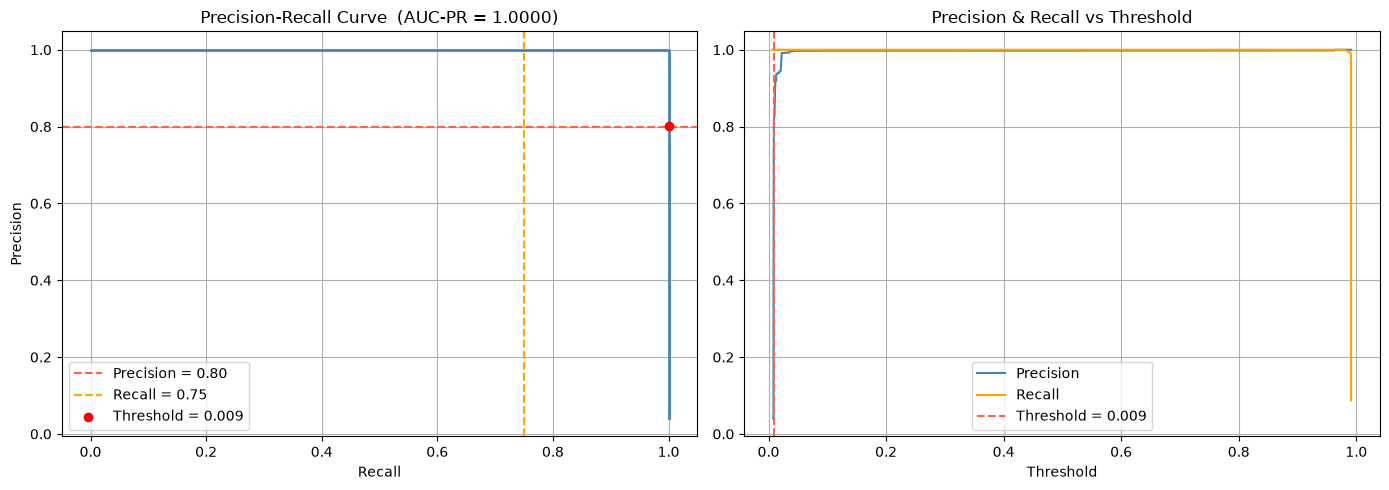

In [62]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color="steelblue", lw=2)
axes[0].axhline(0.80, color="tomato",  linestyle="--", label="Precision = 0.80")
axes[0].axvline(0.75, color="orange",  linestyle="--", label="Recall = 0.75")
if len(candidates) > 0:
    axes[0].scatter(recalls[idx], precisions[idx], color="red", zorder=5,
                    label=f"Threshold = {best_threshold:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve  (AUC-PR = {auc_pr:.4f})")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
axes[1].plot(thresholds, recalls[:-1],    label="Recall",    color="orange")
axes[1].axvline(best_threshold, color="tomato", linestyle="--",
                label=f"Threshold = {best_threshold:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_title("Precision & Recall vs Threshold")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [63]:
# Classification report tại threshold đã chọn
y_pred = (y_prob >= best_threshold).astype(int)
print(f"\n--- Classification Report (threshold = {best_threshold:.4f}) ---")
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))


--- Classification Report (threshold = 0.0091) ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     53039
       Fraud       0.80      1.00      0.89      2280

    accuracy                           0.99     55319
   macro avg       0.90      0.99      0.94     55319
weighted avg       0.99      0.99      0.99     55319



---

In [ ]:
out_path = Path("../data/fraud_model.json")
out_path.parent.mkdir(exist_ok=True)

model.get_booster().save_model(str(out_path))

print(f"Saved : {out_path}")
print(f"Size  : {out_path.stat().st_size / 1024:.1f} KB")
print(f"Threshold dùng trong Flink: {best_threshold:.4f}")

Saved : ../data/fraud_model.json
Size  : 43.9 KB
Threshold dùng trong Flink: 0.0091
